# 01 -- Post-processing & Plotting (DCC process D1, downstream applications)

**SEA-FORWARD** OceanPrediction-A toolkit -- OPERA Capacity Development

SEA-FORWARD implements the **OceanPrediction-A** value chain end to end:

    Upstream Data (U) -> Core Forecasting Engine (C1) -> Verification & Analysis (V1) -> Downstream Applications (D1)

This notebook is **D1**: it takes CROCO output that Core process **C1**
already produced (`sftools`'s CROCO run) and turns it into the static
figures a downstream user actually looks at -- horizontal maps, vertical
sections/profiles, Hovmoller diagrams and time series for SST, SSH,
currents and salinity -- exactly the D1 deliverable SEA-FORWARD's own docs
describe: *"Jupyter notebooks for SST, SSH, currents, MLD and salinity,
with guided exercises"* (see the
[SEA-FORWARD documentation](https://sea-forward.readthedocs.io/en/latest/),
Phase 5 -- [Post-processing](https://sea-forward.readthedocs.io/en/latest/phase5/05_postprocessing/):
[Surface fields](https://sea-forward.readthedocs.io/en/latest/phase5/surface/),
[Dynamics](https://sea-forward.readthedocs.io/en/latest/phase5/dynamics/),
[Vertical structure](https://sea-forward.readthedocs.io/en/latest/phase5/vertical/),
[Through time](https://sea-forward.readthedocs.io/en/latest/phase5/time/)).

`sftools` is used only where it encodes something CROCO-specific -- opening
the run, converting sigma levels to true depths, moving velocities off the
staggered grid, drawing the coastline/land/isobaths consistently. Everything
downstream of that is a single `pl.plot(...)` call per figure.

A D1 product is only as trustworthy as the C1 run it's drawn from --
SEA-FORWARD's own value chain puts **V1** (`02_validation.ipynb` and
`03_composite_validation.ipynb`, RMSE/bias/spatial-correlation/Taylor-diagram
skill against the Copernicus Marine Forecast, satellite SST/SSS and in-situ
observations) *between* C1 and D1 for exactly this reason. This notebook
doesn't re-run that check -- it assumes the cycle you pick below has already
passed (or is being knowingly inspected pre-validation).

**Categories below** (same grouping as the Phase 5 docs pages linked above):

| Section | Content |
|---|---|
| 0 | Find and select a cycle |
| Open data / Parameters | Load the run; the depth/section/profile/isobath settings every figure below reuses |
| 1 -- Surface fields | Temperature, salinity, sea surface height -- the horizontal view where fronts, eddies and large-scale structure show up |
| 2 -- Dynamics | Current speed + vectors, vorticity, combined eddy view -- what the ocean is *doing*, all derived from `u`/`v` rather than read from the file |
| 3 -- Vertical structure | Section and profile (salinity, temperature, speed, u, v) -- CROCO's sigma levels converted to true depths |
| 4 -- Through time | Hovmoller diagrams and time series (salinity, temperature, speed, u, v, SSH) |

**Not covered here:** animations (`06_animation.ipynb`, a separate notebook)
and the validation pass itself (`02_validation.ipynb` /
`03_composite_validation.ipynb`) -- see the closing section for pointers to
both.


In [16]:
import warnings
warnings.filterwarnings("ignore")

import sys, os, re
sys.path.insert(0, "..")   # repo root, so `import sftools...` resolves

import numpy as np
import matplotlib.pyplot as plt

import sftools.postprocess as pp
import sftools.plotting    as pl

%matplotlib inline


## 0. Find and select a cycle

Same discovery pattern as `02_validation.ipynb` Section 1: every run
lives in a cycle directory named `YYYYMMDD`, sibling to every other cycle
under `<MAIN_DIR>/<CONFIG>/`. `RUN_TYPE` distinguishes a forecast cycle
(`fcst/CROCO_FILES/croco_his.nc`) from a hindcast cycle
(`hcast/CROCO_FILES/croco_his.nc`) -- this notebook's original example
pointed at a hindcast run, so that's the default here; set it to `"fcst"`
to browse forecast cycles instead. Every available cycle under
`MAIN_DIR/CONFIG` is listed below; pick one with `CYCLE` (or the
`SEAFORWARD_CYCLE` environment variable).


In [17]:
CONFIG   = os.environ.get("SEAFORWARD_CONFIG", "Canary_12")
RUN_TYPE = os.environ.get("SEAFORWARD_RUN_TYPE", "fcst")   # "fcst" or "hcast"
MAIN_DIR = os.path.expanduser(
    os.environ.get("SEAFORWARD_MAIN_DIR",
                   f"~/seaforward/{'forecast' if RUN_TYPE == 'fcst' else 'hindcast'}/model-runs"))

def _his_path(main_dir, config, cycle, run_type):
    return os.path.join(main_dir, config, cycle, run_type, "CROCO_FILES", "croco_his.nc")

def _list_cycles(main_dir, config, run_type):
    base = os.path.join(main_dir, config)
    if not os.path.isdir(base):
        return []
    return sorted(name for name in os.listdir(base)
                 if re.match(r"^\d{8}$", name)
                 and os.path.exists(_his_path(main_dir, config, name, run_type)))

AVAILABLE_CYCLES = _list_cycles(MAIN_DIR, CONFIG, RUN_TYPE)
print(f"{RUN_TYPE} cycles found under {os.path.join(MAIN_DIR, CONFIG)}: {AVAILABLE_CYCLES}")


fcst cycles found under /home/lell/seaforward/forecast/model-runs/Canary_12: ['20260711', '20260723', '20260729']


In [11]:
# >>> SET THIS to the cycle you want to open, e.g. "20251225_plain" <<<
CYCLE = os.environ.get("SEAFORWARD_CYCLE", "20260729_plain")

# hindcast runs from the GLORYS reanalysis (CF time origin year 1993);
# forecast runs from the Copernicus Marine Forecast / Mercator anfc (2000).
# The wrong Yorig does not crash anything -- the fields are right and every
# date is wrong by years, so it is worth getting this right up front.
YORIG = 1993 if RUN_TYPE == "hcast" else 2000

H = _his_path(MAIN_DIR, CONFIG, CYCLE, RUN_TYPE)
if not os.path.exists(H):
    raise FileNotFoundError(
        f"No CROCO history file for cycle {CYCLE!r} at {H}.\n"
        f"Available {RUN_TYPE} cycles under {os.path.join(MAIN_DIR, CONFIG)}: "
        f"{AVAILABLE_CYCLES if AVAILABLE_CYCLES else '(none found)'}")

print(f"Opening {RUN_TYPE} cycle {CYCLE}")
print(f"  CROCO history: {H}")


Opening fcst cycle 20260729
  CROCO history: /home/lell/seaforward/forecast/model-runs/Canary_12/20260729/fcst/CROCO_FILES/croco_his.nc


## Open data

`open_history()` reads the file and decodes its time axis using `YORIG`
above, so every timestamp that follows (Hovmoller x-axes, time series,
printed dates) is a real calendar date rather than "seconds since
whenever". It also carries the grid (`lon_rho`/`lat_rho`/`mask_rho`,
bathymetry `h`) that every `pl.plot(..., ds=ds, ...)` call below draws
the coastline, land and isobath contours from -- there is no separate
basemap step to set up by hand.

In [18]:
ds = pp.open_history(H, Yorig=YORIG)

n_t = ds.sizes["time"]
t = ds["time"].values
print(f"{n_t} record(s): {str(t[0])[:16]} -> {str(t[-1])[:16]}")
print(f"grid {ds.sizes['xi_rho']} x {ds.sizes['eta_rho']}, {ds.sizes['s_rho']} sigma levels")
if "h" in ds:
    hmask = ds["h"].values[ds["mask_rho"].values > 0] if "mask_rho" in ds else ds["h"].values
    print(f"depth range {np.nanmin(hmask):.0f} to {np.nanmax(hmask):.0f} m")


29 record(s): 2026-07-28T00:00 -> 2026-08-04T00:00
grid 81 x 123, 50 sigma levels
depth range 50 to 4686 m


#### Parameters

In [19]:
# Parameters -- change these and re-run from here.

# Two different depths, deliberately kept separate: "surface fields" (SST,
# SSS, SSH) want the true surface, while "dynamics" (currents, vorticity,
# eddy view) are cleanest below the wind-driven Ekman layer, where the
# mesoscale signal is not swamped by wind-driven transport.
depth     = None                                  # surface-fields depth: None = surface, or metres
dyn_depth = 1000                                  # dynamics-section depth, metres

# section: start -> end (a zonal transect along 21 degN here)
lon0, lat0, lon1, lat1 = -21.0, 21.0, -16.0, 21.0
plon, plat = -19.0, 21.0                          # profile / time-series point

isobaths = [50, 100, 200, 500, 1000, 2000]        # bathymetry contours drawn on every map
tindex = -1                                       # -1 = the last record


---
## 1. Surface fields

The horizontal view -- where fronts, eddies and the large-scale structure
show up. All three maps below use `depth` (surface by default) rather than
`dyn_depth`.

### Temperature

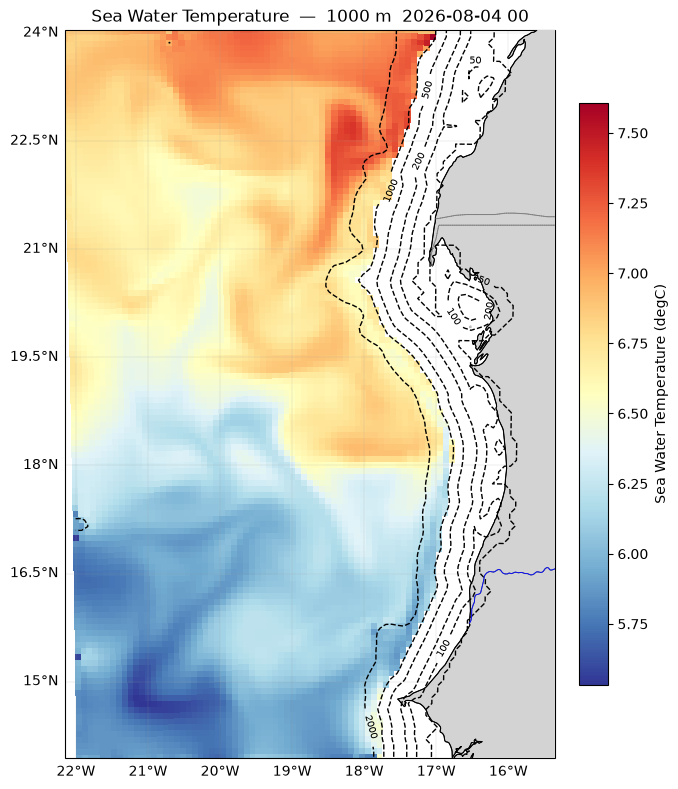

In [21]:
# field() returns a 2D slice: depth=None gives the top sigma level; a
# number gives that true depth in metres, interpolated, with blanks where
# the sea floor is shallower than requested. pl.plot(..., ds=ds,
# isobaths=isobaths) draws the coastline/land/gridlines and labelled
# isobath contours -- no separate basemap step needed.

fig = pl.plot(pp.field(ds, "temp", depth_m=depth, tindex=tindex), ds=ds, isobaths=isobaths)


### Salinity

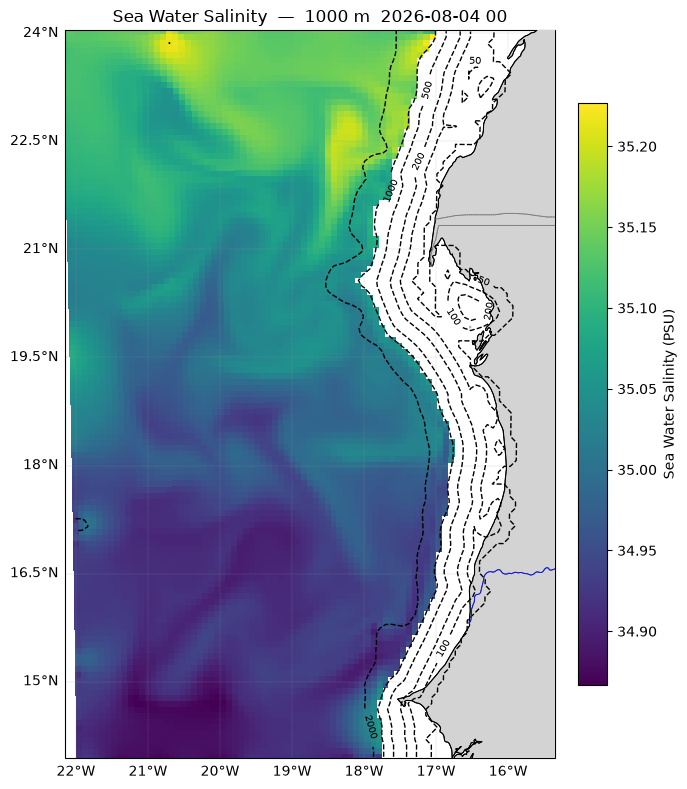

In [23]:
fig = pl.plot(pp.field(ds, "salt", depth_m=depth, tindex=tindex), ds=ds, isobaths=isobaths)


### Sea surface height

CROCO's `zeta` is elevation about the model's own reference level, not an
anomaly about zero -- so the field sits at whatever range it actually
occupies rather than symmetric about zero. `zeta` is already 2D, so no
depth selection applies here (unlike temperature/salinity above).
`cmap="Spectral_r"` matches the diverging-but-off-centre convention used
for SSH throughout the toolkit (see the Dynamics docs page); adjust
`vmin`/`vmax` to your own field's actual range if the default scaling
doesn't suit it.

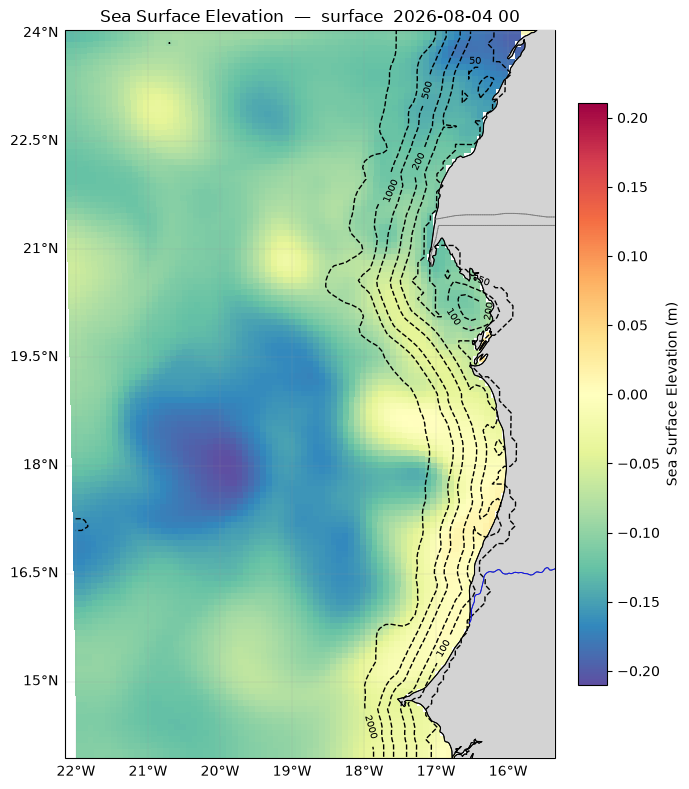

In [24]:
fig = pl.plot(pp.field(ds, "zeta", tindex=tindex), ds=ds, isobaths=isobaths, cmap="Spectral_r")


---
## 2. Dynamics

Currents, vorticity and the eddy field -- what the ocean is *doing* rather
than what it is made of, all derived from `u`/`v` rather than read
directly from the file. Shown at `dyn_depth` (set in Parameters above),
below the wind-driven surface layer, where the mesoscale signal is
cleanest.

### Current & speed at depth

`uv_at_depth(..., rotate=True)` interpolates each velocity column from the
sigma levels to `dyn_depth` and rotates the grid-aligned components to true
east/north in one call -- the averaging of `u`/`v` off CROCO's staggered
Arakawa C-grid onto the rho points happens inside it too.

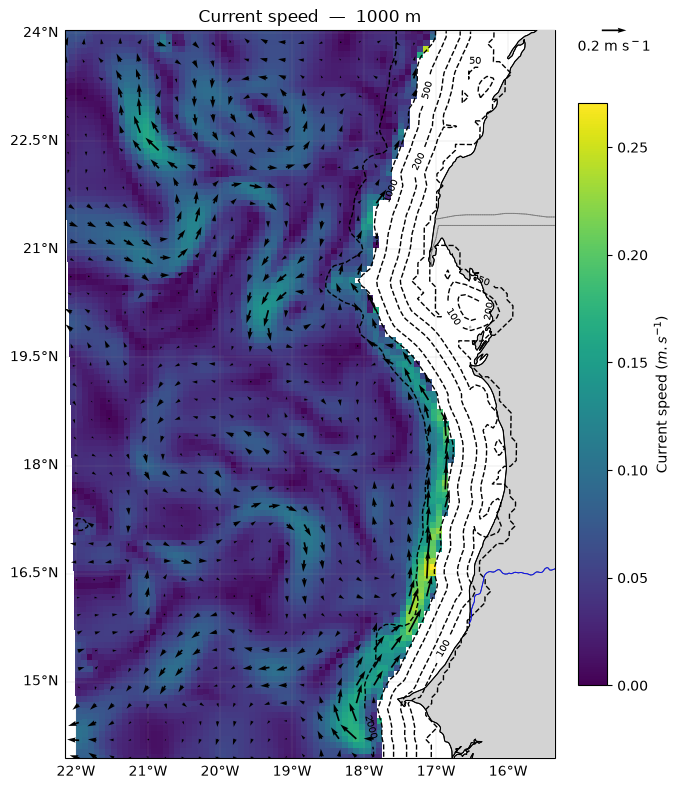

In [25]:
u, v = pp.uv_at_depth(ds, depth_m=dyn_depth, tindex=tindex, rotate=True)  # u, v at dyn_depth, true east/north
fig = pl.plot(pp.speed_map(ds, depth_m=dyn_depth), ds=ds, uv=(u, v), isobaths=isobaths,
             uv_scale=4, uv_skip=3, uv_ref=0.2)


### Vorticity

Relative vorticity normalised by the Coriolis parameter *f* -- dimensionless
and of order +-1 for a strong eddy, computed internally using the grid
metrics `pm`/`pn` (1/dx, 1/dy) rather than a plain, grid-metric-blind
`np.gradient` (CROCO's cells are not square).

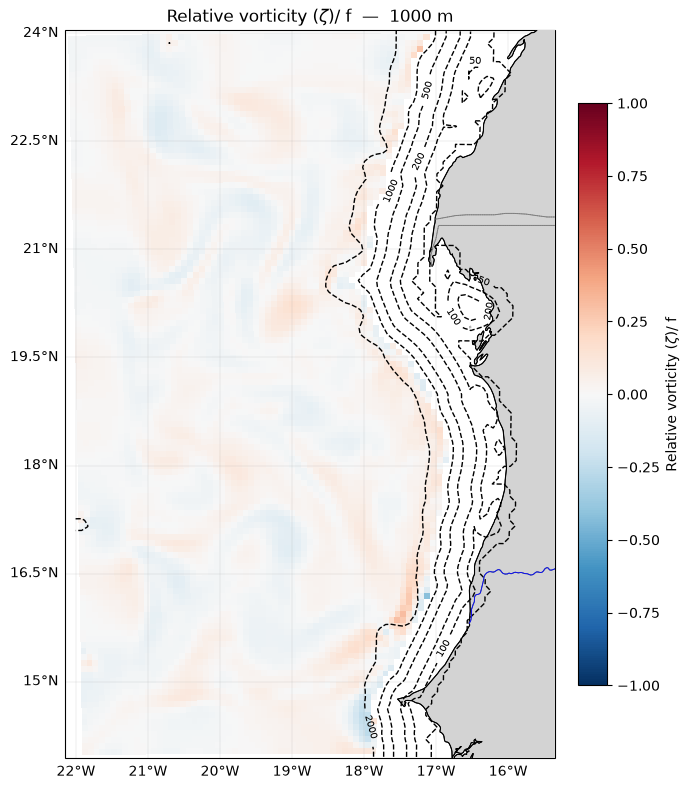

In [27]:
fig = pl.plot(pp.vorticity(ds, depth_m=dyn_depth, normalized=True), ds=ds, isobaths=isobaths)


### Combined eddy view: shaded base field + vorticity contours or current vectors

The most informative single figure in this section, because it shows the
water and what is moving it together. Two variants below -- the same
temperature field at `dyn_depth`, overlaid first with current vectors, then
with vorticity contours (`overlay=('uv', (u, v))` vs. `overlay=('vort',
vort_da)`). The current speed already plotted above is proportional to
kinetic energy (KE = 1/2(u^2+v^2)) -- the jets and eddy cores that stand out
there are the same features this combined view highlights.

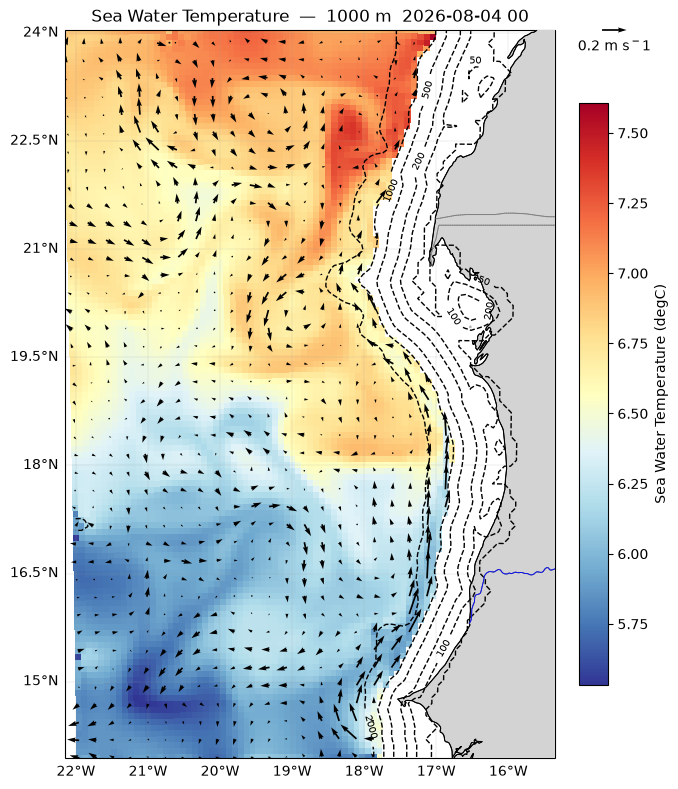

In [86]:
fig = pl.plot_eddy(pp.field(ds, "temp", depth_m=dyn_depth), ds=ds, isobaths=isobaths,
                  overlay=("uv", (u, v)), uv_scale=4, uv_skip=3, uv_ref=0.2)


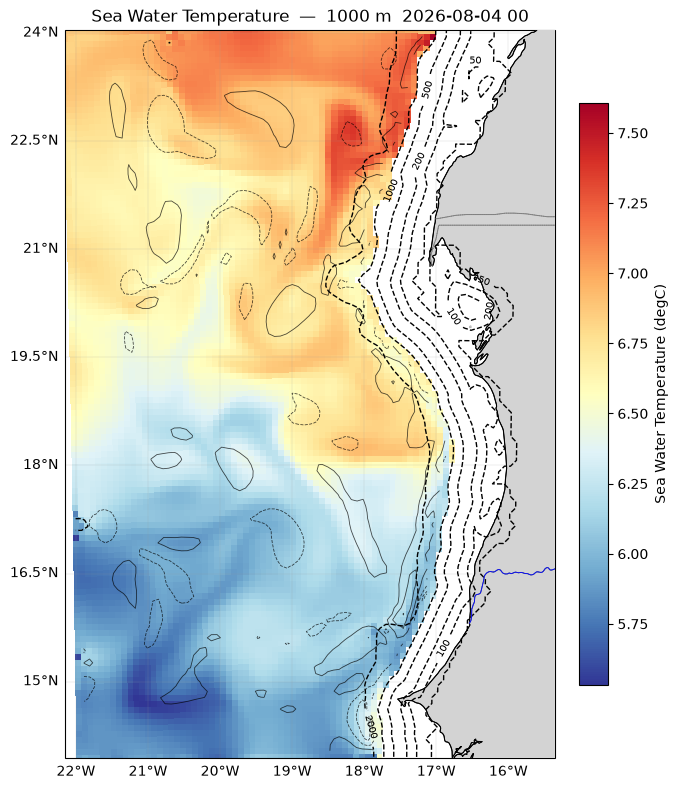

In [87]:
vort_da = pp.vorticity(ds, depth_m=dyn_depth, normalized=True)
fig = pl.plot_eddy(pp.field(ds, "temp", depth_m=dyn_depth), ds=ds, isobaths=isobaths,
                  overlay=("vort", vort_da))


---
## 3. Vertical structure

Below the surface, CROCO's terrain-following sigma levels have to become
true depths -- `pp.section()`/`pp.profile()` handle that conversion
internally (using the file's own `Vtransform`/`hc`/`theta_s`/`theta_b`
stretching parameters), so no separate depth-conversion step is needed
here, unlike a from-scratch implementation.

### Vertical section

#### Salinity

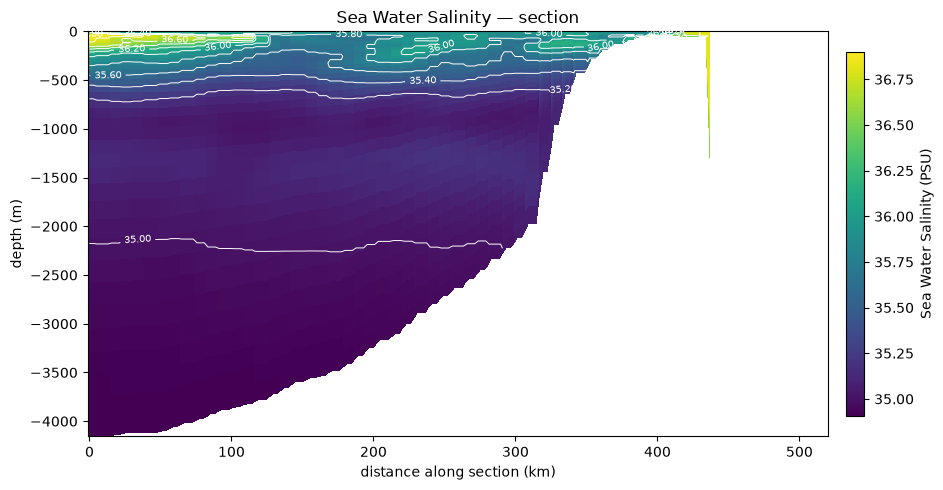

In [28]:
fig = pl.plot(pp.section(ds, "salt", lon0, lon1, lat0, lat1), contour_colors="white", levels=10)


#### Temperature

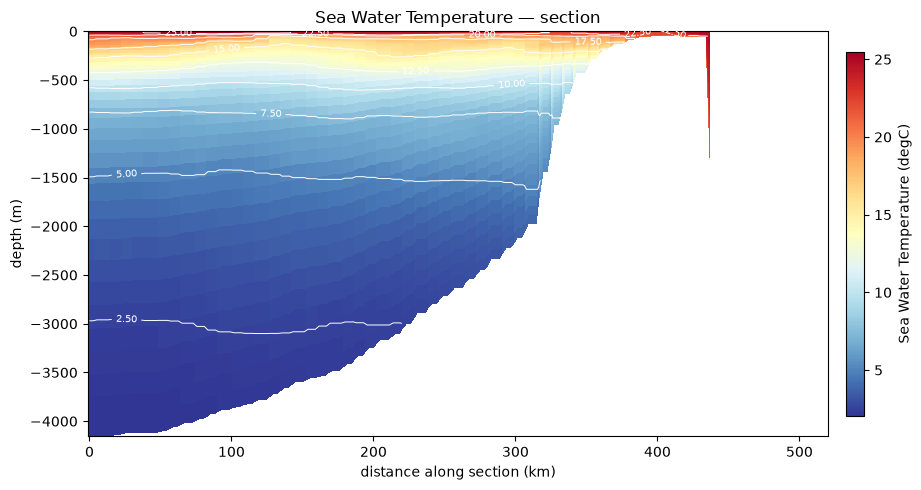

In [29]:
fig = pl.plot(pp.section(ds, "temp", lon0, lon1, lat0, lat1), contour_colors="white", levels=10)


#### Speed

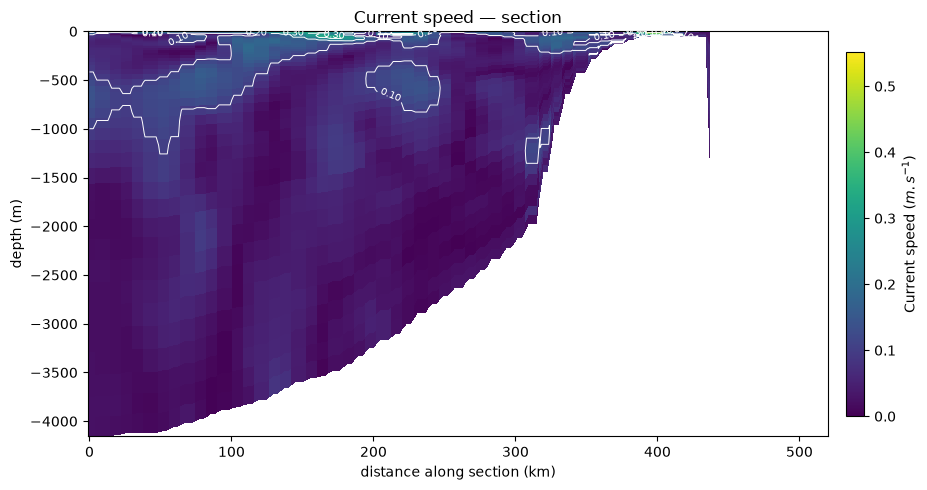

In [30]:
fig = pl.plot(pp.section(ds, "speed", lon0, lon1, lat0, lat1), contour_colors="white", levels=5)


#### Zonal current (u)

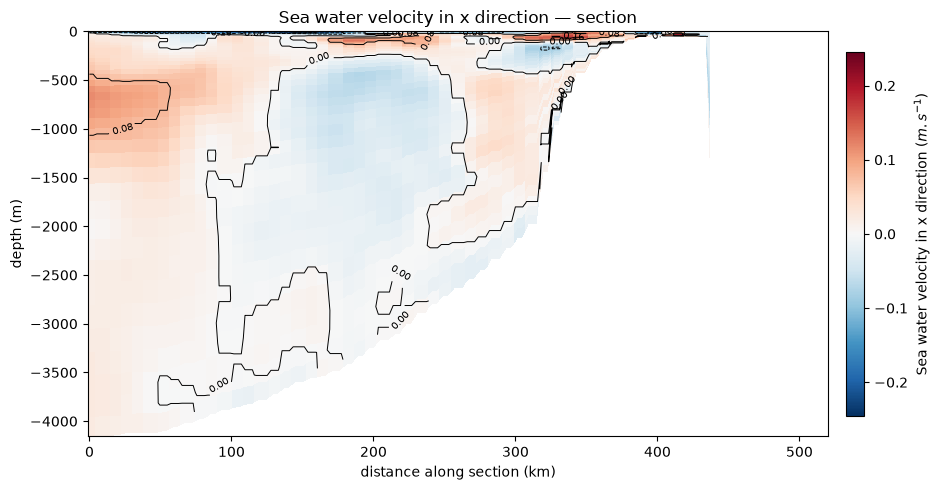

In [31]:
fig = pl.plot(pp.section(ds, "u", lon0, lon1, lat0, lat1), contour_colors="black", levels=5)


#### Meridional current (v)

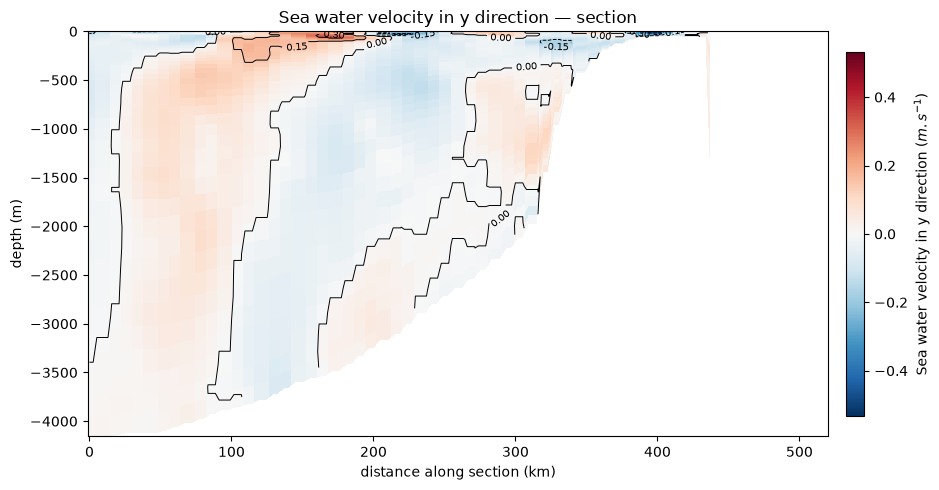

In [32]:
fig = pl.plot(pp.section(ds, "v", lon0, lon1, lat0, lat1), contour_colors="black", levels=5)


### Vertical profile

One column, surface to sea floor, at `(plon, plat)` from Parameters above
-- `pp.profile()` finds the nearest grid cell and reads the whole water
column from it.

#### Salinity

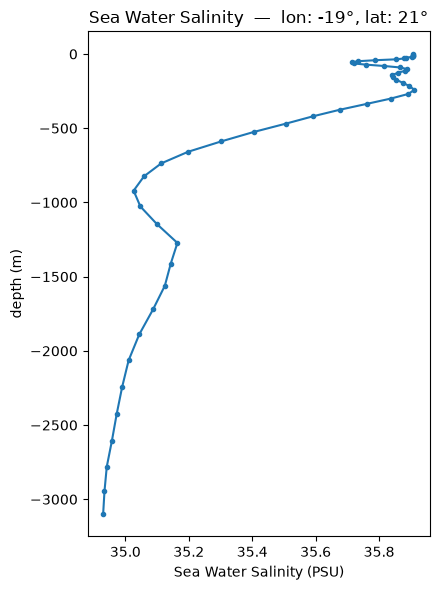

In [33]:
fig = pl.plot(pp.profile(ds, "salt", plon, plat, tindex=tindex))


#### Temperature

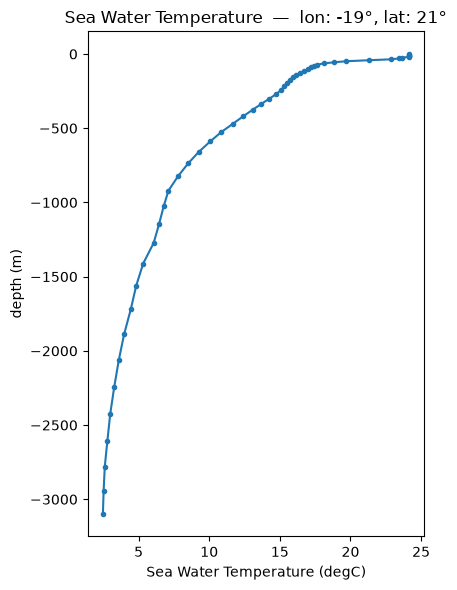

In [99]:
fig = pl.plot(pp.profile(ds, "temp", plon, plat, tindex=tindex))


#### Speed

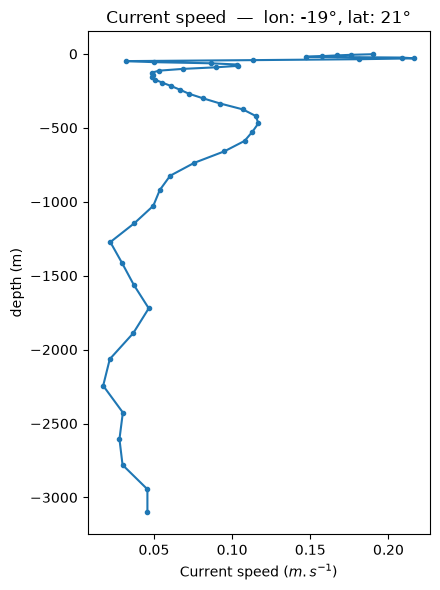

In [100]:
fig = pl.plot(pp.profile(ds, "speed", plon, plat, tindex=tindex))


#### Zonal current (u)

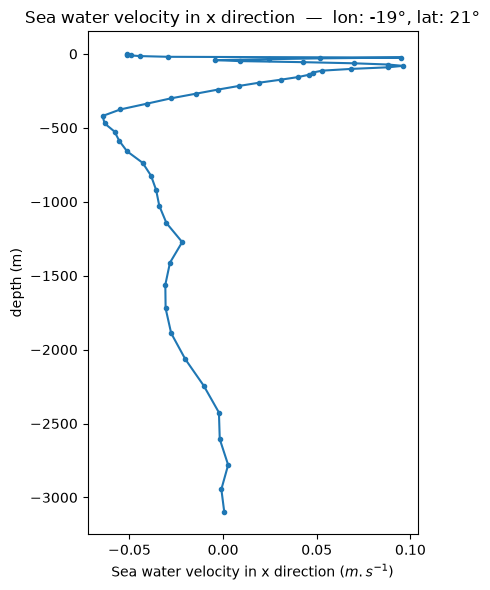

In [101]:
fig = pl.plot(pp.profile(ds, "u", plon, plat, tindex=tindex))


#### Meridional current (v)

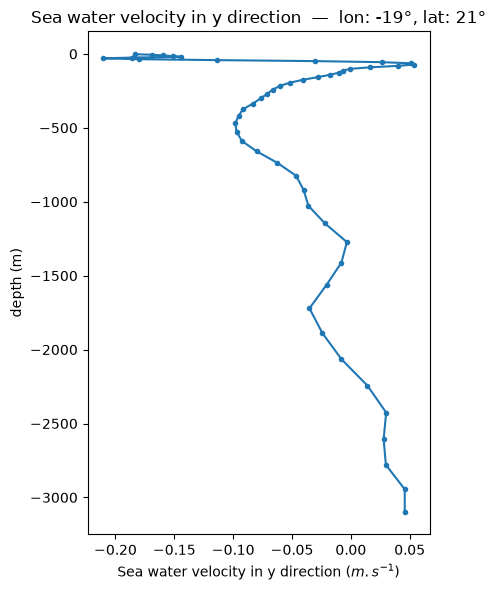

In [102]:
fig = pl.plot(pp.profile(ds, "v", plon, plat, tindex=tindex))


---
## 4. Through time

A **Hovmoller** diagram collapses one spatial dimension against time; a
**time series** follows one point through the run.

### Hovmoller diagrams

`kind="time_lat"` collapses longitude at a fixed `lon0`, so propagating
features (eddies, waves, fronts) appear as bands that *tilt* -- the slope
is their speed. `kind="time_depth"` instead collapses the water column at
one `(lon0, lat0)` point, showing stratification building or breaking down
and the mixed layer deepening.

#### Salinity

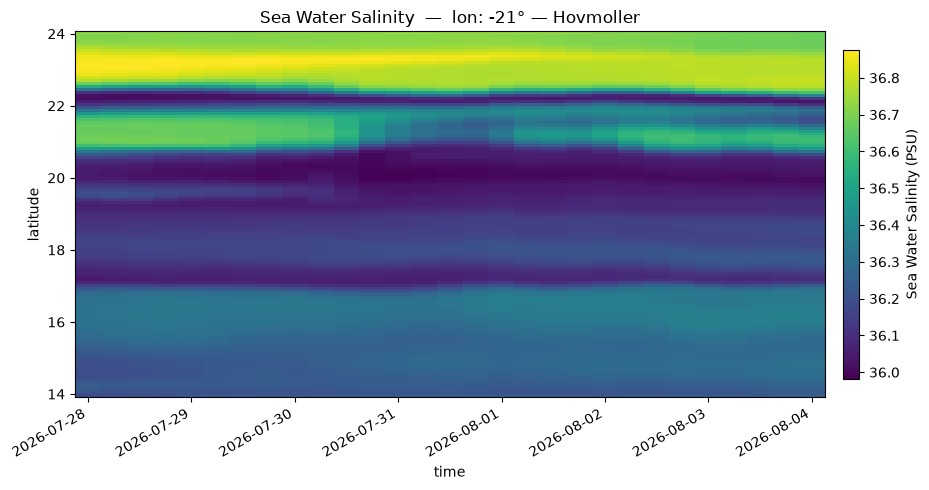

In [103]:
fig = pl.plot(pp.hovmoller(ds, "salt", "time_lat", lon0=lon0))


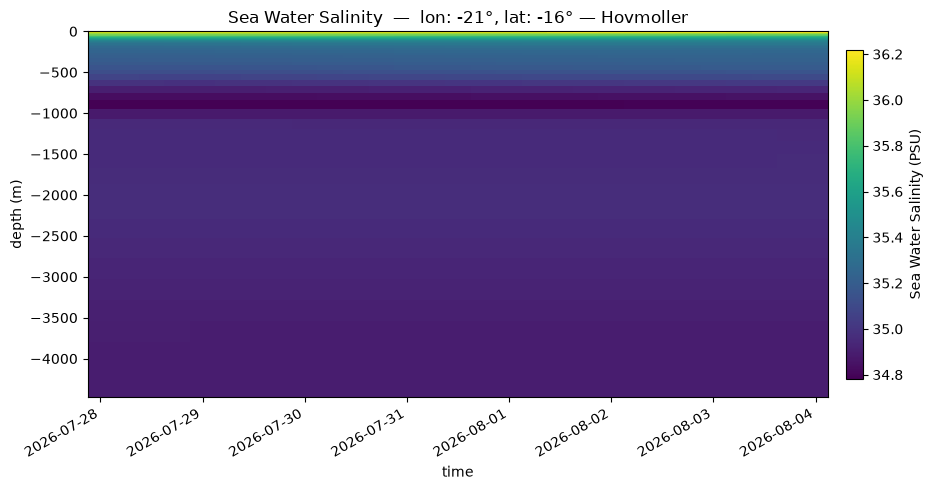

In [104]:
fig = pl.plot(pp.hovmoller(ds, "salt", kind="time_depth", lon0=lon0, lat0=lat0))


#### Temperature

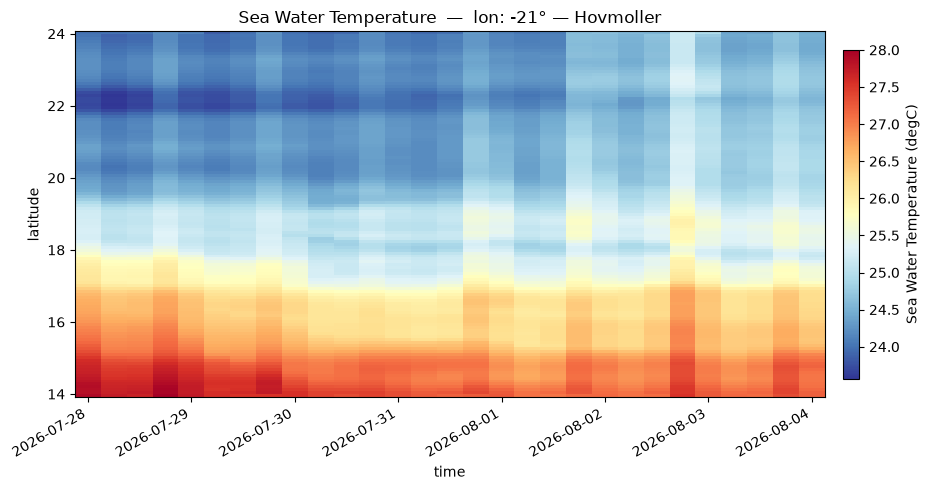

In [105]:
fig = pl.plot(pp.hovmoller(ds, "temp", "time_lat", lon0=lon0))


In [ ]:
fig = pl.plot(pp.hovmoller(ds, "temp", kind="time_depth", lon0=lon0, lat0=lat0))


#### Speed

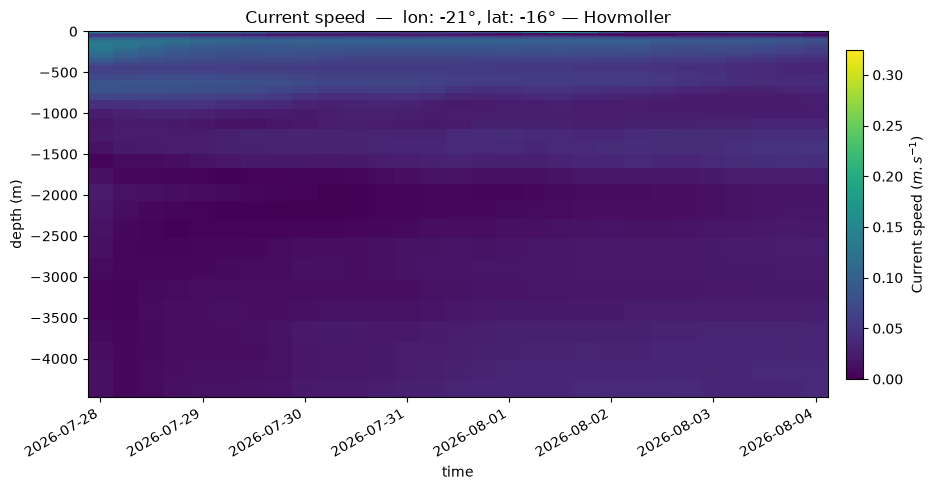

In [106]:
fig = pl.plot(pp.hovmoller(ds, "speed", kind="time_depth", lon0=lon0, lat0=lat0))


#### Zonal current (u)

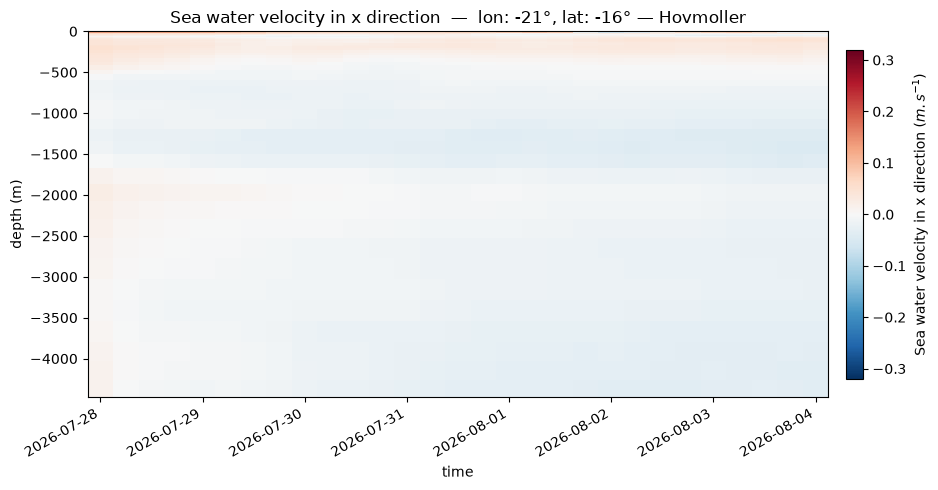

In [107]:
fig = pl.plot(pp.hovmoller(ds, "u", kind="time_depth", lon0=lon0, lat0=lat0))


#### Meridional current (v)

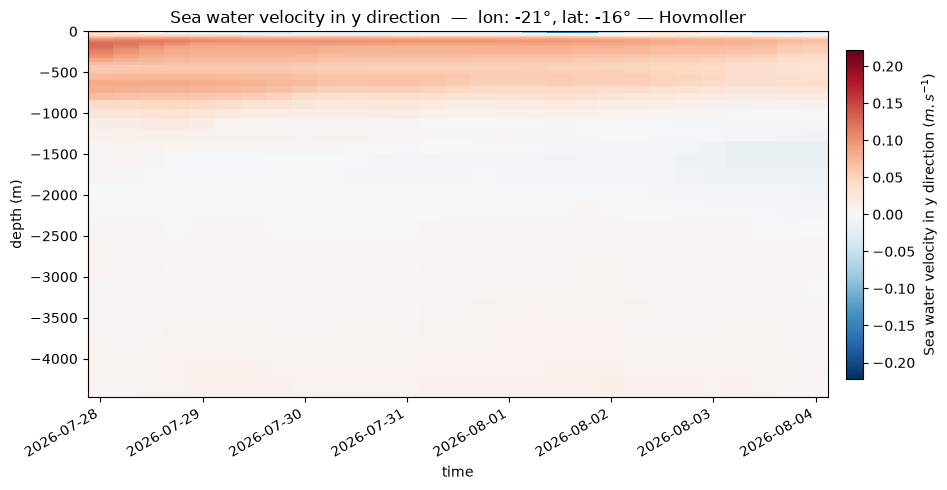

In [108]:
fig = pl.plot(pp.hovmoller(ds, "v", kind="time_depth", lon0=lon0, lat0=lat0))


### Time series

One point through the run -- where diurnal cycles, transient events and
drift show up. The surface carries the diurnal cycle and the atmosphere's
imprint directly; a point at depth usually does not, which is why
temperature/salinity are also shown at `depth_m=50` below alongside the
surface series.

#### SST

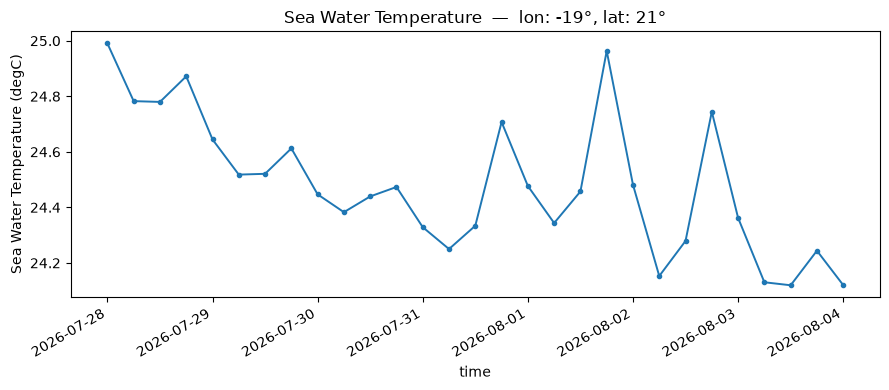

In [109]:
fig = pl.plot(pp.timeseries(ds, "temp", lon0=plon, lat0=plat))


#### Temperature at depth

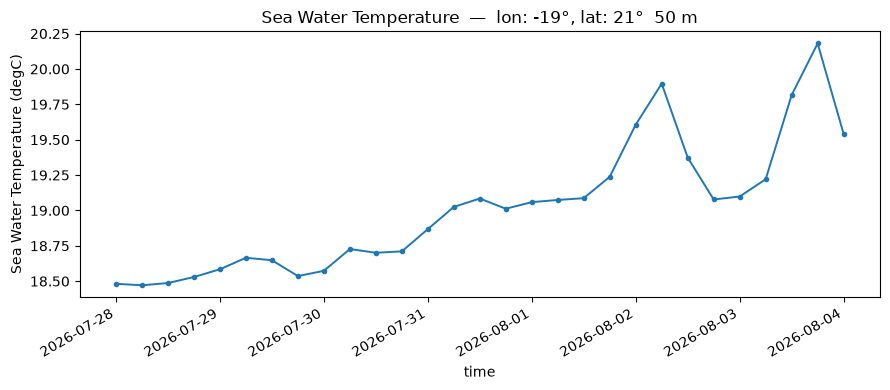

In [110]:
fig = pl.plot(pp.timeseries(ds, "temp", lon0=plon, lat0=plat, depth_m=50))


#### Salinity at depth

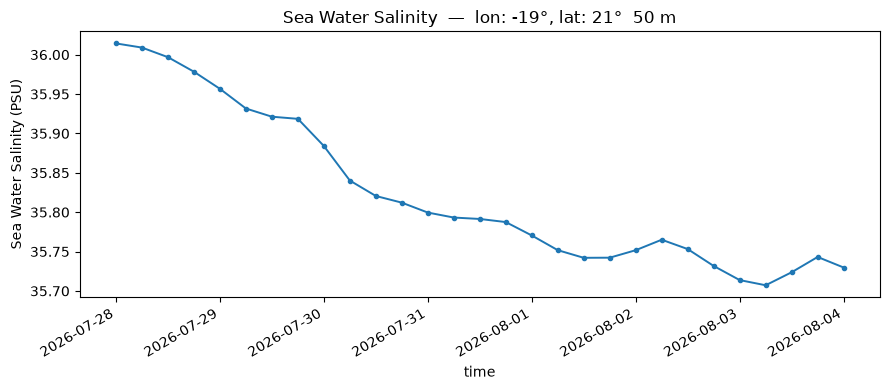

In [111]:
fig = pl.plot(pp.timeseries(ds, "salt", lon0=plon, lat0=plat, depth_m=50))


#### SSH

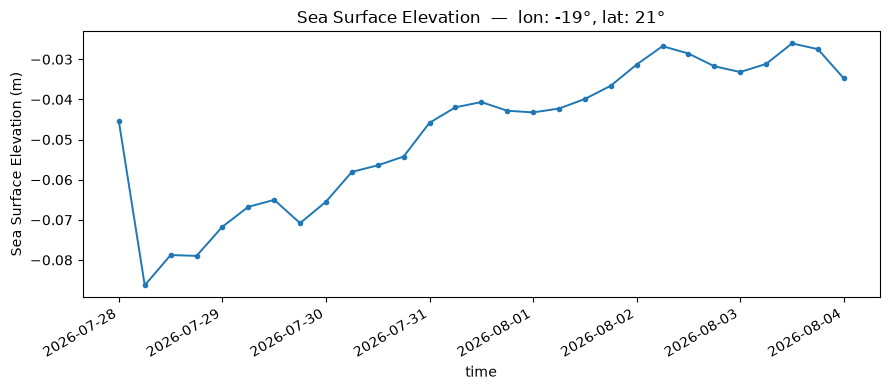

In [112]:
fig = pl.plot(pp.timeseries(ds, "zeta", lon0=plon, lat0=plat))


#### Speed at depth

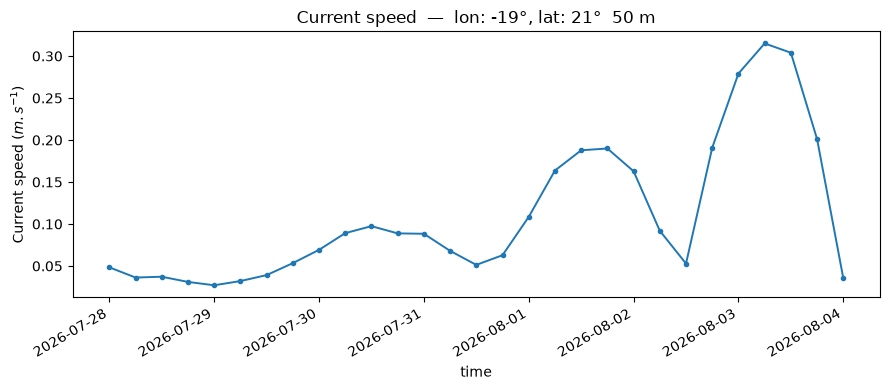

In [113]:
fig = pl.plot(pp.timeseries(ds, "speed", lon0=plon, lat0=plat, depth_m=50))


---
## Saving

Every figure here is a plain matplotlib figure:
add the following as last line to the cell where you plot figure
```python
fig.savefig("/directory/name.png", dpi=250, bbox_inches="tight")
```
- `directory` is the full path to your figure directory 
- `name` is the figure name you want

Add that line at the end of any cell above to save it -- change the path
and filename to suit.

**Next steps:**
- **Validation** -- this notebook doesn't check the run against anything;
  `02_validation.ipynb` (one cycle) and `03_composite_validation.ipynb`
  (several cycles merged by forecast lead time) score it against the
  Copernicus Marine Forecast, satellite SST/SSS and observations.
- **Animations** (SST + wind, SSH + currents at depth, speed at depth,
  particle advection) live in their own notebook, `06_animation.ipynb` --
  not duplicated here.
